This analyse all the results from hyperparameter testing

In [7]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

experiences = {}

def parse_config(folder_name):
    """Extracts parameters from the folder name using regex."""
    pattern = r"(?P<sweep>\w+)_sweep_eta_(?P<eta>[\d.]+)_gamma_(?P<gamma>[\d.]+)_step_(?P<step>\d+)_ddimeta_(?P<ddimeta>[\d.]+)"
    match = re.search(pattern, folder_name)
    if match:
        return match.groupdict()
    return {}

def scan_results(base_dir="results"):
    global experiences
    experiences.clear()
    
    csv_paths = glob.glob(f"{base_dir}/*/*/metrics_sweep.csv")
    
    if not csv_paths:
        print("Error: No 'metrics_sweep.csv' files found. Check your paths.")
        return

    print(f"=== {len(csv_paths)} Indexed Experiments ===\n")
    
    csv_paths.sort(key=os.path.getmtime)
    
    for i, path in enumerate(csv_paths, start=1):
        folder_path = os.path.dirname(path)
        mode = os.path.basename(os.path.dirname(folder_path))
        exp_string = os.path.basename(folder_path)
        
        params = parse_config(exp_string)
        
        if params:
            # Mask the swept parameter with '--'
            sweep_target = params['sweep']
            if sweep_target in params:
                params[sweep_target] = "--"
                
            # Build the clean string
            clean_config = f"Sweep: {params['sweep'].ljust(5)} | η: {params['eta'].ljust(4)} | γ: {params['gamma'].ljust(4)} | Steps: {params['step'].ljust(3)} | ddim_η: {params['ddimeta']}"
        else:
            clean_config = exp_string 
            
        experiences[i] = {
            'path': path,
            'mode': mode,
            'config': clean_config, 
            'params_dict': params
        }
        
        print(f"[{i:02d}] {mode.ljust(18)} -> {clean_config}")

scan_results()

=== 16 Indexed Experiments ===

[01] super_resolution   -> Sweep: gamma | η: 0.07 | γ: --   | Steps: 50  | ddim_η: 0.0
[02] super_resolution   -> Sweep: gamma | η: 0.07 | γ: --   | Steps: 50  | ddim_η: 1.0
[03] super_resolution   -> Sweep: eta   | η: --   | γ: 0.1  | Steps: 50  | ddim_η: 0.0
[04] blur_from_file     -> Sweep: eta   | η: --   | γ: 0.1  | Steps: 50  | ddim_η: 0.0
[05] box_inpainting     -> Sweep: eta   | η: --   | γ: 0.1  | Steps: 50  | ddim_η: 0.0
[06] blur_from_file     -> Sweep: gamma | η: 0.026 | γ: --   | Steps: 50  | ddim_η: 0.0
[07] super_resolution   -> Sweep: gamma | η: 0.7  | γ: --   | Steps: 50  | ddim_η: 0.0
[08] box_inpainting     -> Sweep: gamma | η: 0.078 | γ: --   | Steps: 50  | ddim_η: 0.0
[09] blur_from_file     -> Sweep: eta   | η: --   | γ: 0.036 | Steps: 50  | ddim_η: 0.0
[10] box_inpainting     -> Sweep: eta   | η: --   | γ: 0.036 | Steps: 50  | ddim_η: 0.0
[11] super_resolution   -> Sweep: eta   | η: --   | γ: 0.036 | Steps: 50  | ddim_η: 0.0
[12] b

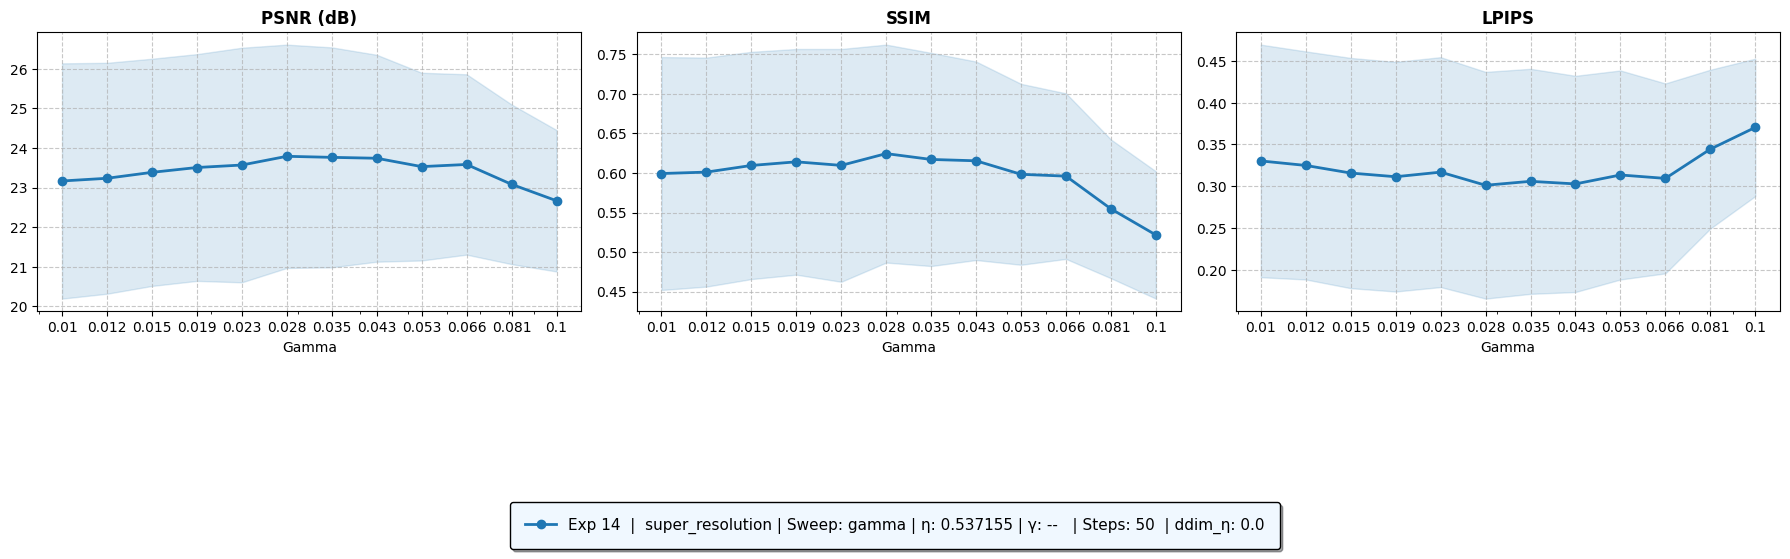

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

def plot_exp(exp_ids, log=True):
    if isinstance(exp_ids, int):
        exp_ids = [exp_ids]
        
    # Figure de base
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    metrics = [
        ('PSNR_mean', 'PSNR_std', 'PSNR (dB)'),
        ('SSIM_mean', 'SSIM_std', 'SSIM'),
        ('LPIPS_mean', 'LPIPS_std', 'LPIPS')
    ]
    
    colors = plt.cm.tab10.colors
    
    # Variables pour stocker les éléments de la légende globale et les axes X
    lines = []
    labels = []
    all_x_values = set()
    
    for idx, exp_id in enumerate(exp_ids):
        if exp_id not in experiences:
            print(f"Erreur : L'expérience [{exp_id}] n'existe pas.")
            continue
            
        exp = experiences[exp_id]
        df = pd.read_csv(exp['path'])
        
        sweep_param_name = df.columns[0]
        x = df[sweep_param_name]
        
        # Stockage des valeurs testées pour forcer les ticks plus tard
        all_x_values.update(x.tolist())
        
        color = colors[idx % len(colors)]
        label = f"Exp {exp_id}  |  {exp['mode']} | {exp['config']}"
        
        for i, (ax, (col_mean, col_std, title)) in enumerate(zip(axes, metrics)):
            y = df[col_mean]
            y_err = df[col_std]
            
            # 1. Création des masques pour séparer le succès de l'échec
            valid_mask = ~y.isna()
            nan_mask = y.isna()
            
            line = None
            
            # 2. Tracé des valeurs valides
            if valid_mask.any():
                line, = ax.plot(x[valid_mask], y[valid_mask], marker='o', linewidth=2, color=color)
                ax.fill_between(x[valid_mask], y[valid_mask] - y_err[valid_mask], y[valid_mask] + y_err[valid_mask], color=color, alpha=0.15)
            
            # 3. Tracé des échecs (NaN) avec des marqueurs explicites en bas du graphe
            if nan_mask.any():
                # On utilise transform=ax.get_xaxis_transform() pour fixer le Y à 5% (0.05) de la hauteur de l'axe, 
                # indépendamment des valeurs réelles de PSNR/SSIM/LPIPS.
                ax.scatter(x[nan_mask], [0.05] * nan_mask.sum(), marker='X', s=120, 
                           color=color, edgecolor='red', linewidth=1.5, zorder=10, 
                           transform=ax.get_xaxis_transform())
            
            # Mise en forme du subplot
            ax.set_title(title, fontweight='bold')
            ax.set_xlabel(sweep_param_name.capitalize())
            ax.grid(True, linestyle='--', alpha=0.7)

            if log:
                ax.set_xscale('log')
            
                
            # 4. Gestion de la légende (capturée uniquement sur la première itération)
            if i == 0:
                if line is not None:
                    lines.append(line)
                else:
                    # Si TOUTE l'expérience a échoué, on crée une fausse ligne pour la légende
                    dummy_line = mlines.Line2D([], [], color=color, marker='X', markersize=10, markeredgecolor='red')
                    lines.append(dummy_line)
                labels.append(label)

    # Forcer l'affichage strict des valeurs testées sur l'axe X
    if all_x_values:
        sorted_x = sorted(list(all_x_values))
        for ax in axes:
            ax.set_xticks(sorted_x)
            ax.set_xticklabels([f"{val:.2g}" for val in sorted_x])

    # Placement de la légende globale sous les graphes
    if lines:
        fig.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 0), 
                   ncol=1, fontsize=11, frameon=True, shadow=True, 
                   edgecolor='black', facecolor='aliceblue', borderpad=1)

    # Ajustement strict des marges pour ne pas écraser la légende
    plt.tight_layout(rect=[0, 0.25, 1, 1])
    plt.show()

# Exemple d'utilisation
plot_exp([14])

In [9]:
def find_best_hyperparameters():
    # 1. Regrouper les expériences par mode (box_inpainting, super_resolution, etc.)
    modes_dict = {}
    for exp_id, exp in experiences.items():
        mode = exp['mode']
        if mode not in modes_dict:
            modes_dict[mode] = []
        modes_dict[mode].append((exp_id, exp))
        
    if not modes_dict:
        print("Aucune expérience en mémoire. Lance scan_results() d'abord.")
        return

    # 2. Analyser et afficher les meilleurs résultats
    for mode, exps in modes_dict.items():
        print(f"=== Mode : {mode.upper()} ===")
        
        for exp_id, exp in exps:
            try:
                df = pd.read_csv(exp['path'])
            except Exception as e:
                print(f"  [Exp {exp_id}] Erreur de lecture du CSV.")
                continue
                
            sweep_param = df.columns[0]
            
            # Filtrer les lignes où les métriques ont planté (NaN)
            valid_df = df.dropna(subset=['PSNR_mean', 'SSIM_mean', 'LPIPS_mean'])
            
            if valid_df.empty:
                print(f"  [Exp {exp_id}] Échec total. Le modèle a divergé (NaN) sur toute la plage de {sweep_param}.")
                continue
                
            # Extraire la plage testée
            val_min = df[sweep_param].min()
            val_max = df[sweep_param].max()
            
            # Trouver les index des meilleures métriques (PSNR/SSIM = max, LPIPS = min)
            best_psnr_idx = valid_df['PSNR_mean'].idxmax()
            best_ssim_idx = valid_df['SSIM_mean'].idxmax()
            best_lpips_idx = valid_df['LPIPS_mean'].idxmin()
            
            # Extraire la valeur de l'hyperparamètre correspondant
            best_param_psnr = valid_df.loc[best_psnr_idx, sweep_param]
            best_param_ssim = valid_df.loc[best_ssim_idx, sweep_param]
            best_param_lpips = valid_df.loc[best_lpips_idx, sweep_param]
            
            # Formater les paramètres fixes pour l'affichage
            fixed_params = []
            if exp['params_dict']:
                for key, value in exp['params_dict'].items():
                    # On ignore le nom du balayage et la valeur masquée "--"
                    if key != 'sweep' and value != '--':
                        fixed_params.append(f"{key}={value}")
            fixed_str = ", ".join(fixed_params) if fixed_params else "Paramètres non parsés"
            
            # Affichage propre
            print(f"  Exp {exp_id} : {sweep_param} [{val_min:g}, {val_max:g}], {fixed_str}")
            print(f"         -> Meilleur {sweep_param} | PSNR: {best_param_psnr:g} | SSIM: {best_param_ssim:g} | LPIPS: {best_param_lpips:g}\n")
        print("-" * 60)

# Lancer l'analyse
find_best_hyperparameters()

=== Mode : SUPER_RESOLUTION ===
  Exp 1 : gamma [0.01, 0.12], eta=0.07, step=50, ddimeta=0.0
         -> Meilleur gamma | PSNR: 0.01 | SSIM: 0.01 | LPIPS: 0.01

  Exp 2 : gamma [0.01, 0.12], eta=0.07, step=50, ddimeta=1.0
         -> Meilleur gamma | PSNR: 0.01 | SSIM: 0.01 | LPIPS: 0.01

  Exp 3 : eta [0.2, 20], gamma=0.1, step=50, ddimeta=0.0
         -> Meilleur eta | PSNR: 0.702238 | SSIM: 0.702238 | LPIPS: 0.702238

  Exp 7 : gamma [0.0001, 5], eta=0.7, step=50, ddimeta=0.0
         -> Meilleur gamma | PSNR: 0.036566 | SSIM: 0.036566 | LPIPS: 0.036566

  Exp 11 : eta [0.5, 1.1], gamma=0.036, step=50, ddimeta=0.0
         -> Meilleur eta | PSNR: 0.537155 | SSIM: 0.537155 | LPIPS: 0.537155

  Exp 14 : gamma [0.01, 0.1], eta=0.537155, step=50, ddimeta=0.0
         -> Meilleur gamma | PSNR: 0.02848 | SSIM: 0.02848 | LPIPS: 0.02848

------------------------------------------------------------
=== Mode : BLUR_FROM_FILE ===
  Exp 4 : eta [0.0001, 20], gamma=0.1, step=50, ddimeta=0.0
    

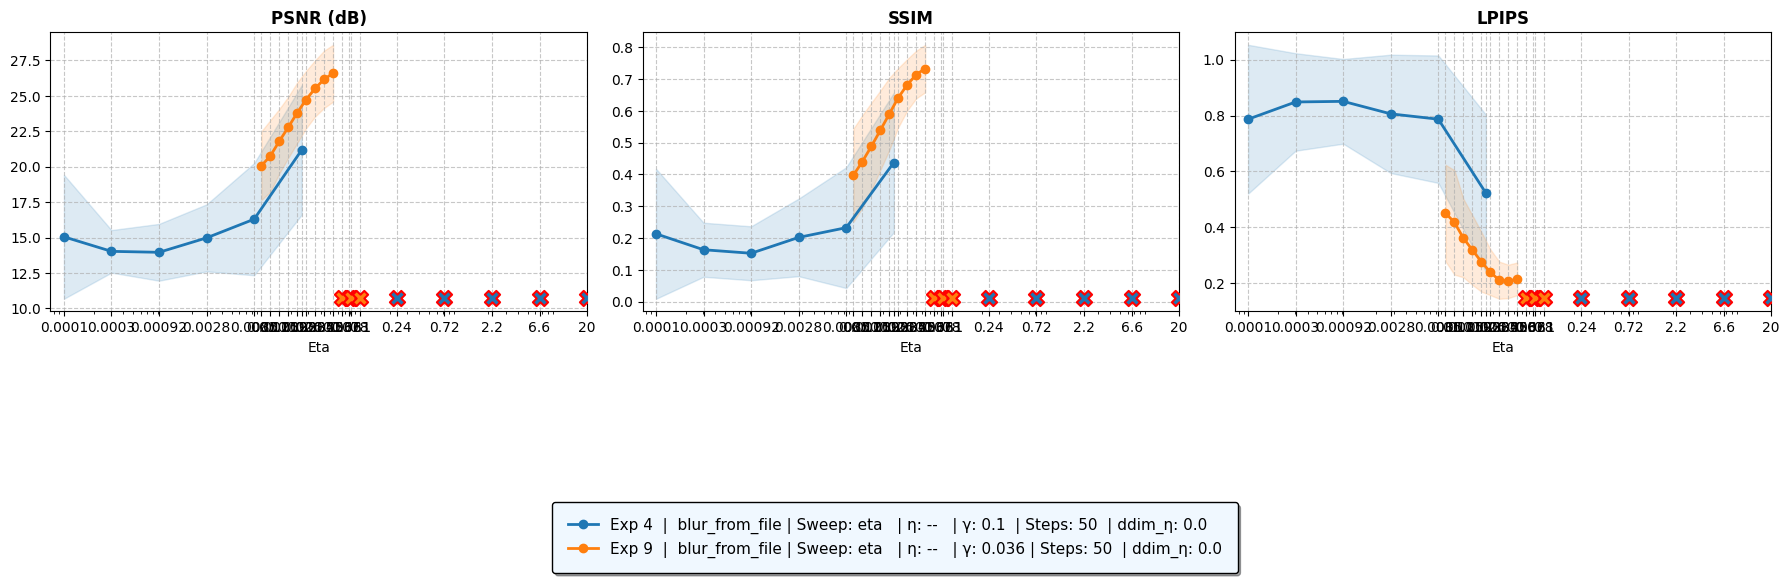

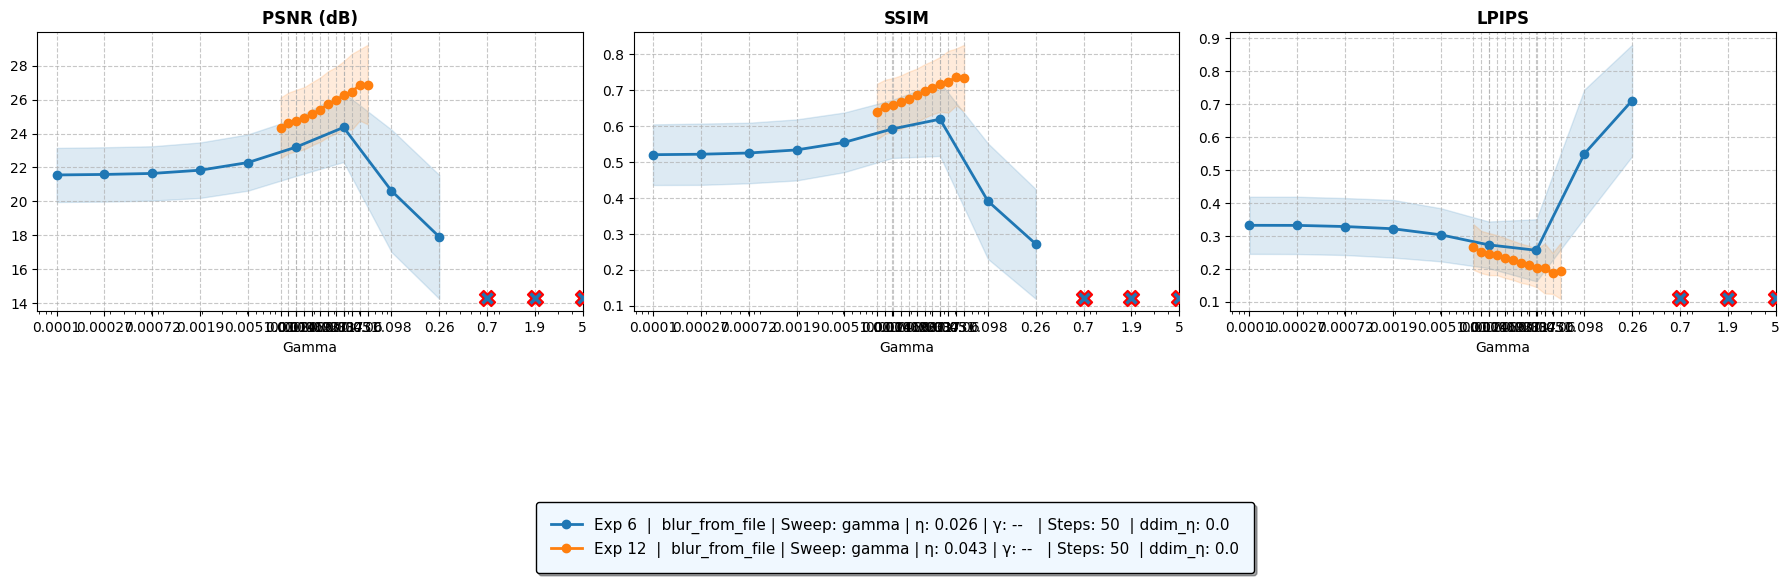

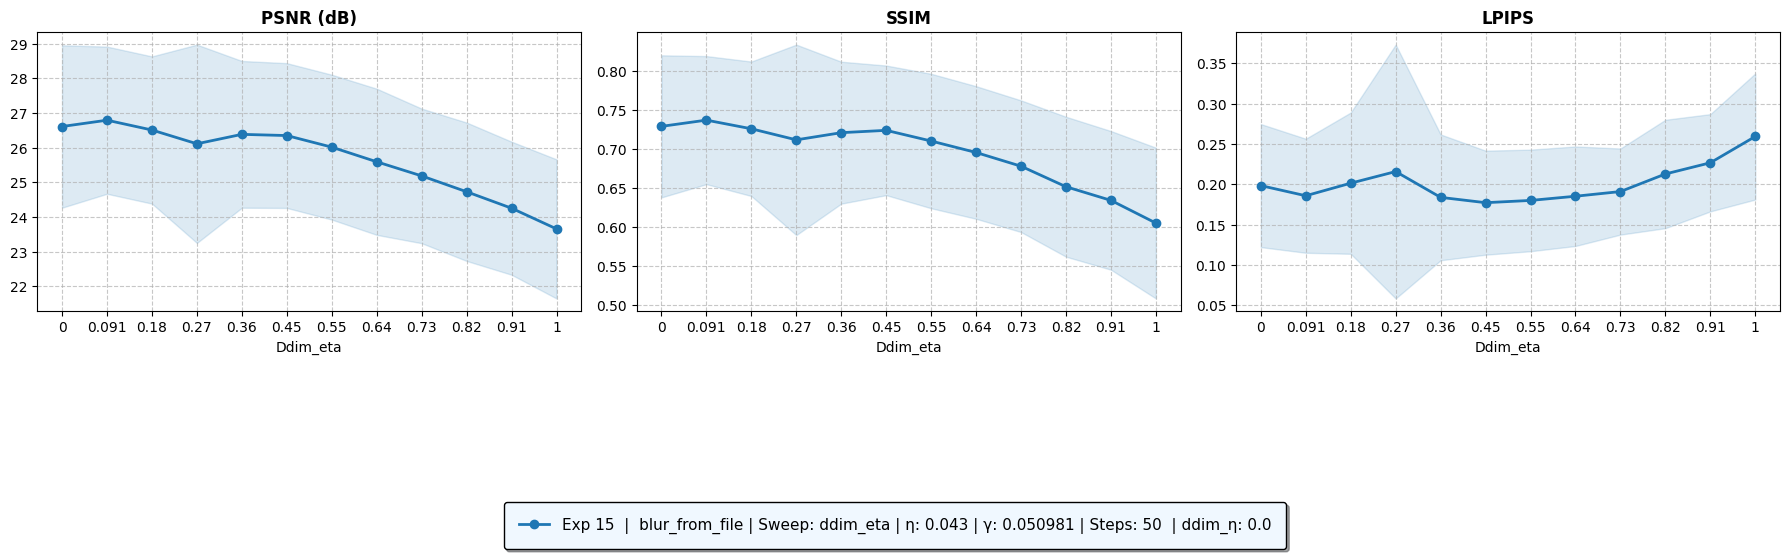

In [12]:
plot_exp([4, 9])
plot_exp([6, 12])
plot_exp([15], log=False)

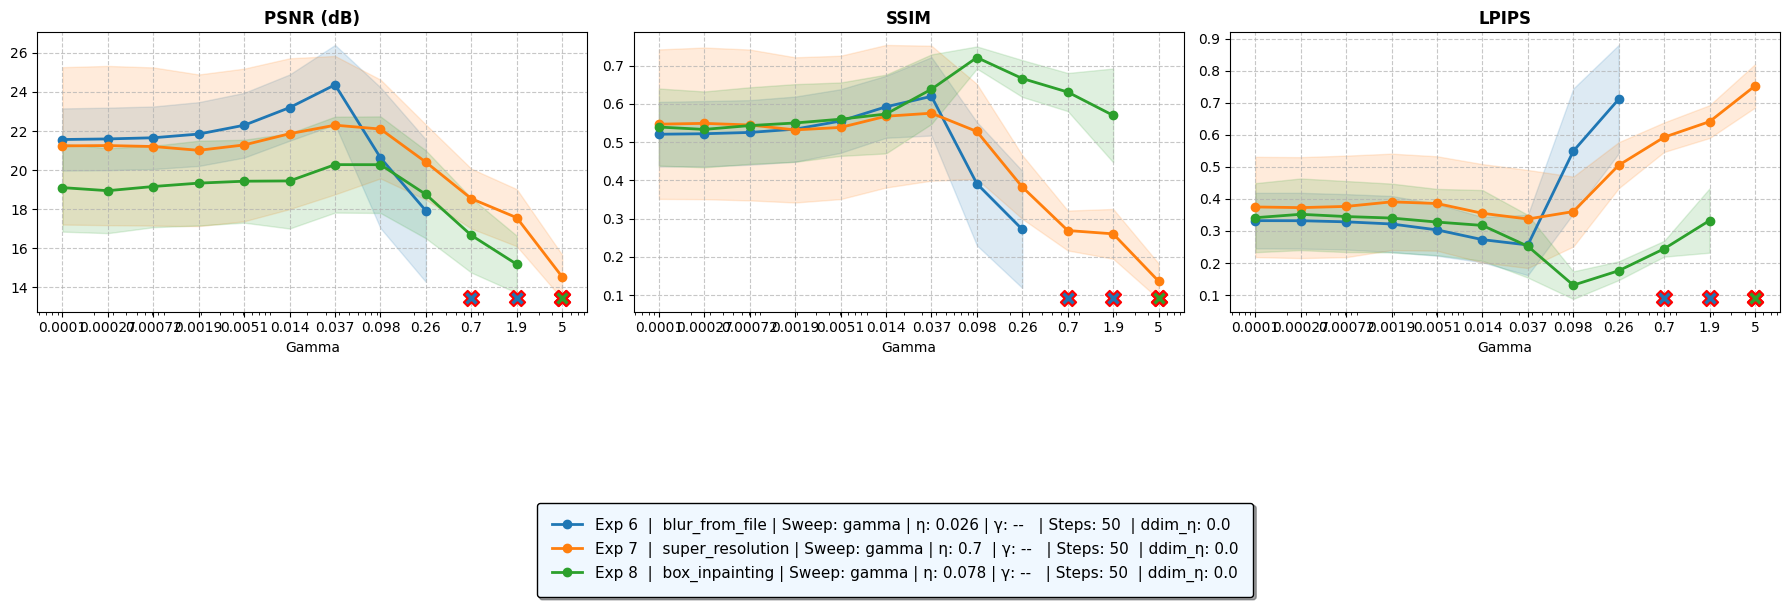

In [14]:
plot_exp([6, 7, 8])
